# TCGA LUAD — Multi-Modal Survival Analysis
**Dataset:** TCGA Lung Adenocarcinoma, Pan-Cancer Atlas 2018 (cBioPortal)  
**N:** 505 patients (566 total, 61 excluded — missing OS)  
**Goal:** RWE analysis integrating clinical and molecular biomarker data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from pathlib import Path

df = pd.read_csv("../data/processed/clinical_clean.csv")
df = df.dropna(subset=["OS_MONTHS"])
print("Working n:", len(df))
print("OS events:", df["OS_EVENT"].sum())

In [18]:
COLORS = {
    "primary":   "#2E4057",
    "secondary": "#048A81",
    "accent":    "#54C6EB",
    "warm":      "#E76F51",
    "gray":      "#6C757D",
    "light":     "#F4F1DE",
}

## 1. Overall Survival
Kaplan-Meier estimate for the full cohort. Median OS and confidence interval shown.

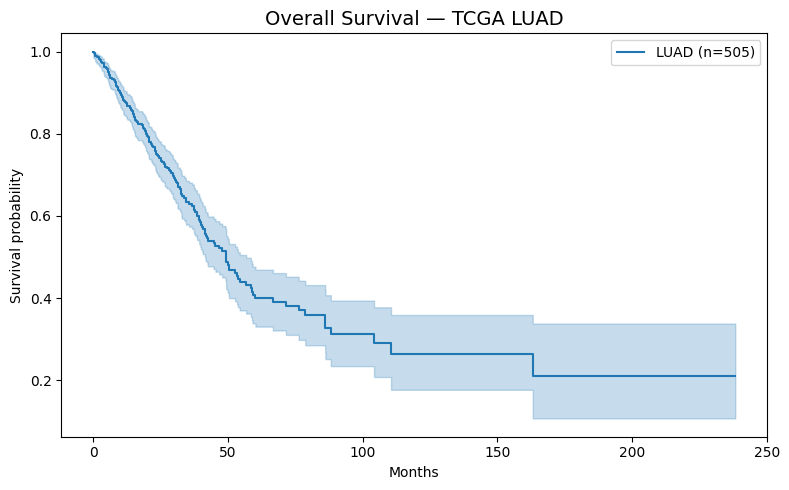

Median OS: 49.28165171


In [2]:
kmf = KaplanMeierFitter()
kmf.fit(df["OS_MONTHS"], df["OS_EVENT"], label="LUAD (n={})".format(len(df)))

fig, ax = plt.subplots(figsize=(8,5))
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_title("Overall Survival — TCGA LUAD", fontsize=14)
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
plt.tight_layout()
plt.savefig("figures/fig1_km_overall.png", dpi=150)
plt.show()
print("Median OS:", kmf.median_survival_time_)

## 2. Survival by Pathologic Stage
Stage is the primary clinical prognosticator in LUAD. We expect clear separation across stages, consistent with published literature.

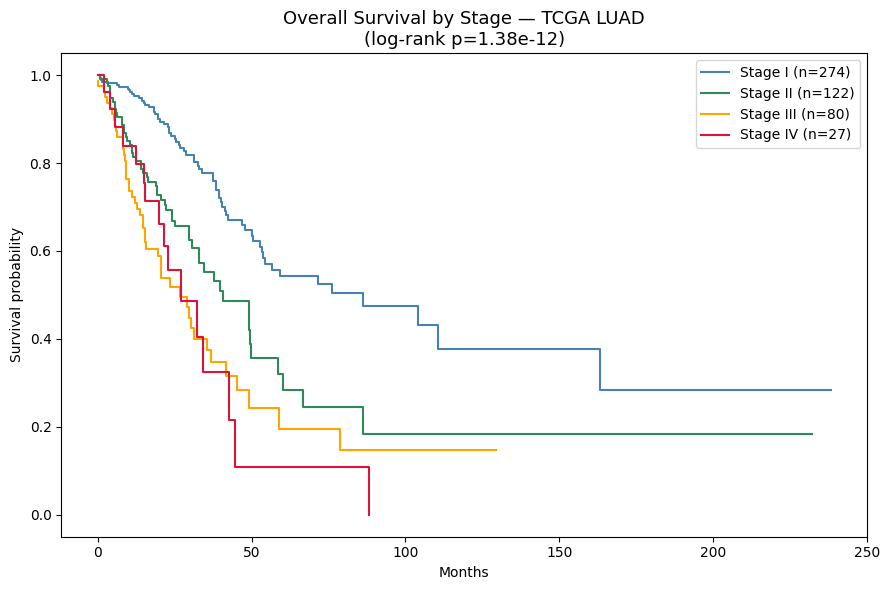

In [3]:
fig, ax = plt.subplots(figsize=(9,6))

colors = {"I": "steelblue", "II": "seagreen", "III": "orange", "IV": "crimson"}

for stage, group in df.groupby("STAGE_SIMPLE"):
    if pd.isna(stage):
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(group["OS_MONTHS"], group["OS_EVENT"], 
            label=f"Stage {stage} (n={len(group)})")
    kmf.plot_survival_function(ax=ax, ci_show=False, color=colors.get(stage))

# Log-rank test
from lifelines.statistics import multivariate_logrank_test
df_stage = df.dropna(subset=["STAGE_SIMPLE"])
results = multivariate_logrank_test(df_stage["OS_MONTHS"], 
                                     df_stage["STAGE_SIMPLE"], 
                                     df_stage["OS_EVENT"])

ax.set_title(f"Overall Survival by Stage — TCGA LUAD\n(log-rank p={results.p_value:.2e})", fontsize=13)
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig2_km_stage.png", dpi=150)
plt.show()

Stage separation is highly significant (log-rank p=1.38e-12). Stage I patients show dramatically better long-term survival, with a plateau suggesting a subset of long-term survivors. Notably, Stage III and IV curves cross early (~10 months), which may reflect more aggressive treatment in Stage III patients — this will be explored in the treatment analysis section.

## 3. Survival by Molecular Subtype
TCGA LUAD includes molecularly-defined subtypes based on multi-omic profiling. Unlike purely clinical staging, molecular subtypes capture tumor biology and may provide prognostic value independent of stage.

In [4]:
print("Subtypes disponibles:\n", df["SUBTYPE"].value_counts())

Subtypes disponibles:
 SUBTYPE
LUAD    493
Name: count, dtype: int64


In [5]:
print("TMB stats:")
print(df["TMB_NONSYNONYMOUS"].describe())
print("\nMissing:", df["TMB_NONSYNONYMOUS"].isna().sum())

TMB stats:
count    505.000000
mean      10.180924
std       10.682106
min        0.000000
25%        2.733333
50%        6.833333
75%       13.833333
max       67.200000
Name: TMB_NONSYNONYMOUS, dtype: float64

Missing: 0


In [6]:
# TMB alto vs bajo usando threshold clínico FDA (≥10)
df["TMB_GROUP"] = df["TMB_NONSYNONYMOUS"].apply(
    lambda x: "High (≥10)" if x >= 10 else "Low (<10)"
)
print(df["TMB_GROUP"].value_counts())

TMB_GROUP
Low (<10)     326
High (≥10)    179
Name: count, dtype: int64


## 4. Survival by Tumor Mutational Burden (TMB)
TMB measures the number of somatic mutations per megabase. High TMB (≥10 mut/Mb) 
is an FDA-approved biomarker for immunotherapy eligibility across tumor types. 
We stratify patients using this clinical threshold to assess its prognostic value in LUAD.

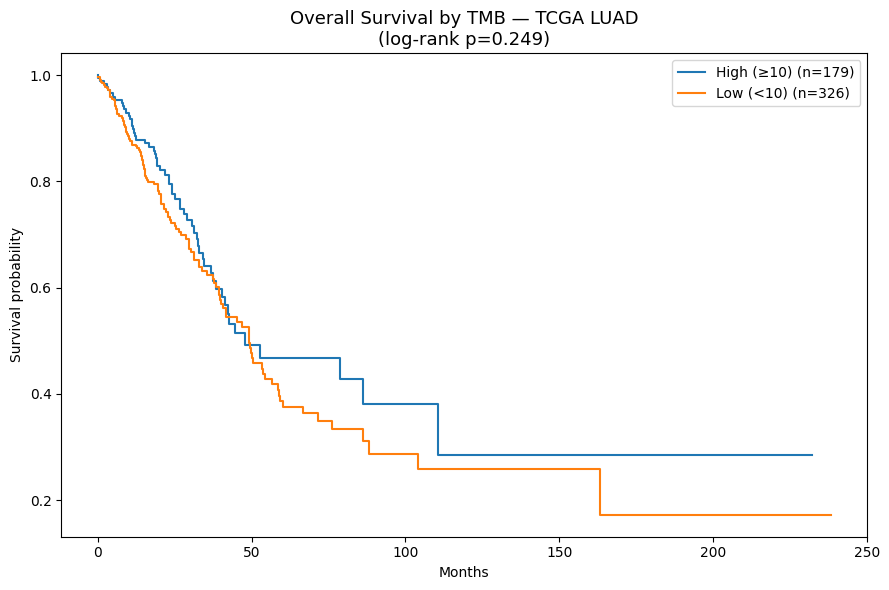

In [7]:
fig, ax = plt.subplots(figsize=(9,6))

for group, data in df.groupby("TMB_GROUP"):
    kmf = KaplanMeierFitter()
    kmf.fit(data["OS_MONTHS"], data["OS_EVENT"], label=f"{group} (n={len(data)})")
    kmf.plot_survival_function(ax=ax, ci_show=False)

from lifelines.statistics import logrank_test
low = df[df["TMB_GROUP"] == "Low (<10)"]
high = df[df["TMB_GROUP"] == "High (≥10)"]
lr = logrank_test(low["OS_MONTHS"], high["OS_MONTHS"],
                  low["OS_EVENT"], high["OS_EVENT"])

ax.set_title(f"Overall Survival by TMB — TCGA LUAD\n(log-rank p={lr.p_value:.3f})", fontsize=13)
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig3_km_tmb.png", dpi=150)
plt.show()

TMB does not show significant overall prognostic value (log-rank p=0.249), consistent 
with TCGA data predating widespread immunotherapy use. However, a visual separation 
emerges after ~50 months, with TMB-high patients showing better long-term survival — 
suggesting TMB may be more relevant as a predictive biomarker for immunotherapy response 
than as a general prognostic factor. This hypothesis will be revisited in the 
mutation analysis section.

In [8]:
print("MSI stats:")
print(df["MSI_SENSOR_SCORE"].describe())
print("\nMissing:", df["MSI_SENSOR_SCORE"].isna().sum())

MSI stats:
count    504.000000
mean       0.143472
std        0.482977
min        0.000000
25%        0.000000
50%        0.010000
75%        0.100000
max        6.820000
Name: MSI_SENSOR_SCORE, dtype: float64

Missing: 1


In [9]:
print("MSI-High (≥3.5):", (df["MSI_SENSOR_SCORE"] >= 3.5).sum())
print("MSI-Low (<3.5):", (df["MSI_SENSOR_SCORE"] < 3.5).sum())

MSI-High (≥3.5): 3
MSI-Low (<3.5): 501


## 5. Microsatellite Instability (MSI)
MSI-High is a pan-tumor biomarker for immunotherapy response (pembrolizumab FDA-approved). 
In colorectal cancer, MSI-High reaches ~15% of patients. In LUAD, only 3/504 patients 
(0.6%) meet the MSI-High threshold (≥3.5) — consistent with published literature showing 
LUAD is predominantly microsatellite stable. MSI is therefore not a clinically actionable 
stratification factor in this cohort and is not analyzed further.

In [10]:
mutations = pd.read_csv(
    "../data/raw/luad_tcga_pan_can_atlas_2018/data_mutations.txt",
    sep="\t", low_memory=False
)
print("Shape:", mutations.shape)
print("Columns:", mutations.columns.tolist()[:10])
print("\nTop mutated genes:")
print(mutations["Hugo_Symbol"].value_counts().head(15))

Shape: (243229, 114)
Columns: ['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome', 'Start_Position', 'End_Position', 'Strand', 'Consequence', 'Variant_Classification']

Top mutated genes:
Hugo_Symbol
TTN       1040
MUC16      617
RYR2       542
CSMD3      522
LRP1B      435
USH2A      404
ZFHX4      375
TP53       343
FLG        298
XIRP2      295
SPTA1      276
FAT3       256
PCDH15     230
CSMD1      224
ZNF536     223
Name: count, dtype: int64


In [11]:
genes_of_interest = ["EGFR", "KRAS", "TP53", "STK11", "KEAP1", "ALK", "ROS1", "BRAF", "MET"]

for gene in genes_of_interest:
    n = (mutations["Hugo_Symbol"] == gene).sum()
    print(f"{gene}: {n} mutations")

EGFR: 93 mutations
KRAS: 186 mutations
TP53: 343 mutations
STK11: 93 mutations
KEAP1: 111 mutations
ALK: 69 mutations
ROS1: 35 mutations
BRAF: 51 mutations
MET: 29 mutations


In [12]:
# Pacientes mutados por gen (uno o más)
mutated_patients = {}
for gene in genes_of_interest:
    mutated = mutations[mutations["Hugo_Symbol"] == gene]["Tumor_Sample_Barcode"].unique()
    # TCGA sample IDs tienen formato TCGA-XX-XXXX-01 — necesitamos match con PATIENT_ID
    # Extraemos los primeros 12 caracteres
    patient_ids = set([s[:12] for s in mutated])
    mutated_patients[gene] = patient_ids
    print(f"{gene}: {len(patient_ids)} patients mutated")

EGFR: 75 patients mutated
KRAS: 168 patients mutated
TP53: 295 patients mutated
STK11: 77 patients mutated
KEAP1: 104 patients mutated
ALK: 48 patients mutated
ROS1: 33 patients mutated
BRAF: 42 patients mutated
MET: 26 patients mutated


## 6. Driver Mutation Analysis
LUAD is characterized by distinct oncogenic driver mutations with therapeutic implications. 
We analyze the most clinically relevant genes: EGFR and KRAS (the two most common drivers), 
TP53 (tumor suppressor), STK11 and KEAP1 (co-mutations associated with poor prognosis), 
and targetable alterations (ALK, ROS1, BRAF, MET).

Mutation status is extracted from somatic variant calls and mapped to patient-level binary 
flags for survival analysis.

In [13]:
# Agregar flags al dataframe clinical
for gene in genes_of_interest:
    df[f"{gene}_MUT"] = df["PATIENT_ID"].isin(mutated_patients[gene]).astype(int)

# Verificar
print("Mutation prevalence in clinical cohort:")
for gene in genes_of_interest:
    n = df[f"{gene}_MUT"].sum()
    pct = n/len(df)*100
    print(f"  {gene}: {n} ({pct:.1f}%)")

Mutation prevalence in clinical cohort:
  EGFR: 70 (13.9%)
  KRAS: 155 (30.7%)
  TP53: 262 (51.9%)
  STK11: 75 (14.9%)
  KEAP1: 96 (19.0%)
  ALK: 39 (7.7%)
  ROS1: 31 (6.1%)
  BRAF: 41 (8.1%)
  MET: 21 (4.2%)


### EGFR and KRAS — The Two Major Drivers
EGFR and KRAS are the most frequent and clinically relevant driver mutations in LUAD. 
EGFR mutations are targetable with tyrosine kinase inhibitors (erlotinib, osimertinib) 
and associated with better prognosis. KRAS mutations (historically undruggable, now 
partially targetable with sotorasib) are more common and generally associated with 
worse outcomes. We expect opposite survival patterns for these two drivers.

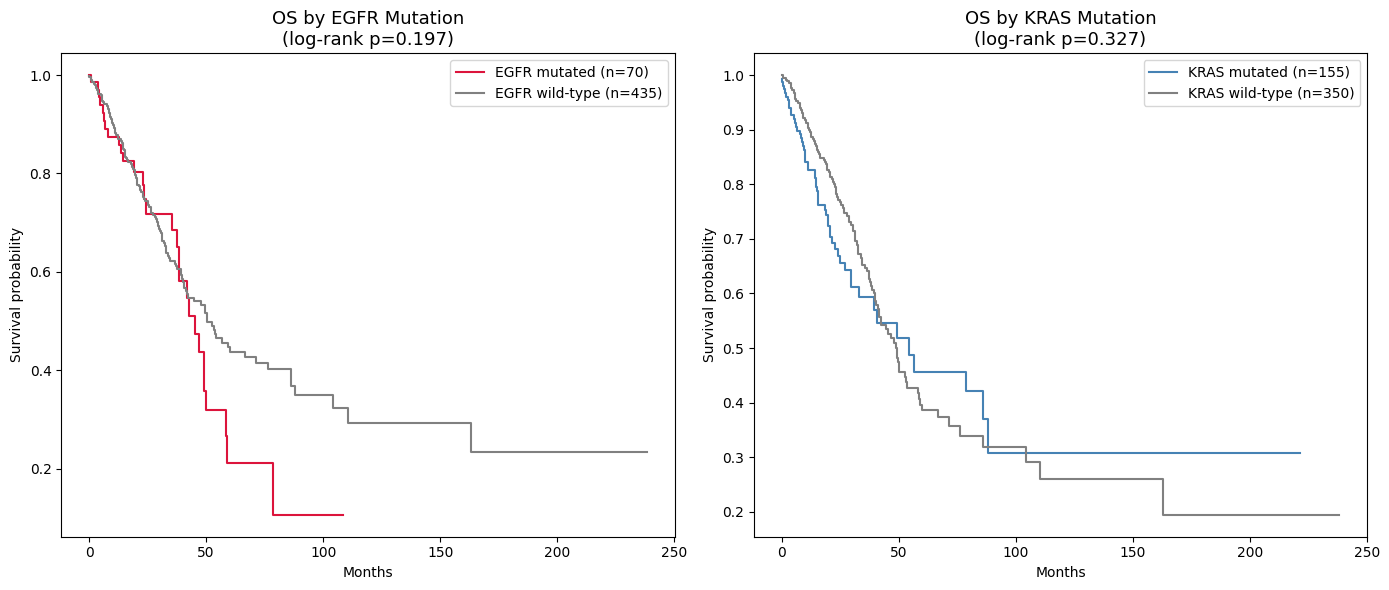

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, gene, color_mut, color_wt in zip(
    axes, 
    ["EGFR", "KRAS"],
    ["crimson", "steelblue"],
    ["gray", "gray"]
):
    for status, label, color in [
        (1, f"{gene} mutated", color_mut),
        (0, f"{gene} wild-type", color_wt)
    ]:
        group = df[df[f"{gene}_MUT"] == status]
        kmf = KaplanMeierFitter()
        kmf.fit(group["OS_MONTHS"], group["OS_EVENT"],
                label=f"{label} (n={len(group)})")
        kmf.plot_survival_function(ax=ax, ci_show=False, color=color)

    # Log-rank
    mut = df[df[f"{gene}_MUT"] == 1]
    wt  = df[df[f"{gene}_MUT"] == 0]
    lr = logrank_test(mut["OS_MONTHS"], wt["OS_MONTHS"],
                      mut["OS_EVENT"], wt["OS_EVENT"])

    ax.set_title(f"OS by {gene} Mutation\n(log-rank p={lr.p_value:.3f})", fontsize=13)
    ax.set_xlabel("Months")
    ax.set_ylabel("Survival probability")
    ax.legend()

plt.tight_layout()
plt.savefig("figures/fig4_km_egfr_kras.png", dpi=150)
plt.show()

EGFR-mutated patients show a trend toward worse overall survival, with no patients 
surviving beyond 120 months compared to long-term survivors in the wild-type group. 
However, this does not reach statistical significance (p=0.197), likely due to limited 
power with only 70 EGFR-mutated patients. This finding is counterintuitive given that 
EGFR mutations are targetable — but may reflect that TCGA patients predate widespread 
use of third-generation TKIs (osimertinib), and that EGFR-mutated tumors may have 
higher recurrence rates despite initial treatment response.

KRAS mutation shows no clear prognostic effect (p=0.327), consistent with its role 
as a driver rather than a pure prognostic biomarker in the pre-sotorasib era.
The KRAS survival curves cross multiple times, indicating no consistent directional 
effect over time and suggesting heterogeneity within the KRAS-mutated group. 
KRAS comprises multiple subtypes (G12C, G12V, G12D) with distinct biology — 
this will be explored in the mutation co-occurrence analysis.    

## 7. KRAS Subtype Analysis (G12C, G12V, G12D)

KRAS is the most common driver mutation in LUAD (~30%), but it comprises 
multiple subtypes with distinct biology and therapeutic implications:

- **G12C** (n=70) — the most common subtype; targetable with sotorasib 
  (AMG 510) and adagrasib (MRTX849), FDA-approved since 2021/2022
- **G12V** (n=40) — associated with worse prognosis; no approved targeted 
  therapy as of TCGA data collection
- **G12D** (n=20) — emerging target; clinical trials ongoing

We ask: do KRAS subtypes have distinct survival profiles, or is the 
heterogeneity within KRAS-mutated patients driven by subtype differences?

In [16]:
# Reload data with mutation columns
df = pd.read_csv("../data/processed/clinical_clean.csv")
df = df.dropna(subset=["OS_MONTHS"])
print("Working n:", len(df))
print("\nKRAS group distribution:\n", df["KRAS_GROUP"].value_counts())

Working n: 509

KRAS group distribution:
 KRAS_GROUP
WT          350
G12C         66
G12V         36
G12other     21
G12D         18
other        18
Name: count, dtype: int64


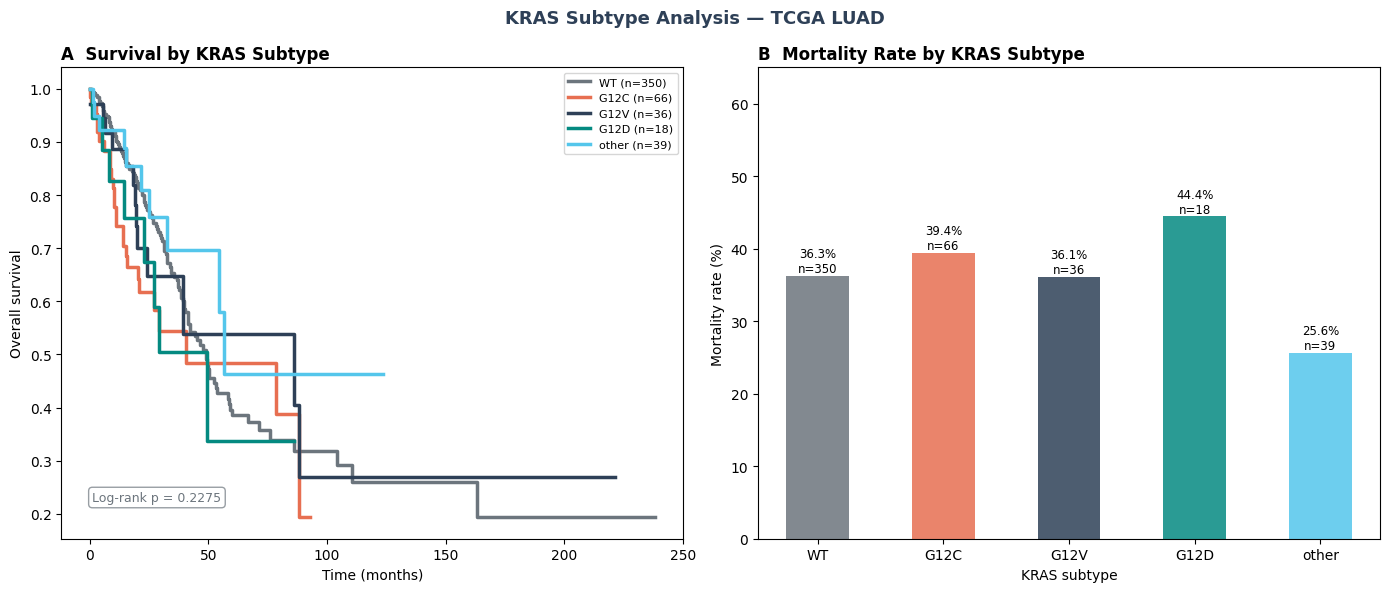

In [19]:
KRAS_COLORS = {
    "WT":      COLORS["gray"],
    "G12C":    COLORS["warm"],
    "G12V":    COLORS["primary"],
    "G12D":    COLORS["secondary"],
    "other":   COLORS["accent"],
}

# Combine G12other + other → other
df["KRAS_PLOT"] = df["KRAS_GROUP"].replace({"G12other": "other"})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("white")

# Panel A — KM by KRAS subtype
ax0 = axes[0]
kras_order = ["WT", "G12C", "G12V", "G12D", "other"]
for group in kras_order:
    mask = df["KRAS_PLOT"] == group
    if mask.sum() < 5:
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, "OS_MONTHS"], df.loc[mask, "OS_EVENT"],
            label=f"{group} (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax0, ci_show=False,
                               color=KRAS_COLORS[group], lw=2.5)

groups_for_test = df[df["KRAS_PLOT"].isin(kras_order)]
res = multivariate_logrank_test(groups_for_test["OS_MONTHS"],
                                 groups_for_test["KRAS_PLOT"],
                                 groups_for_test["OS_EVENT"])
ax0.text(0.05, 0.08, f"Log-rank p = {res.p_value:.4f}",
         transform=ax0.transAxes, fontsize=9, color=COLORS["gray"],
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["gray"], alpha=0.7))
ax0.set_xlabel("Time (months)")
ax0.set_ylabel("Overall survival")
ax0.set_title("A  Survival by KRAS Subtype", fontweight="bold", loc="left")
ax0.legend(fontsize=8, loc="upper right")

# Panel B — Event rate by KRAS subtype
ax1 = axes[1]
kras_stats = []
for group in kras_order:
    mask = df["KRAS_PLOT"] == group
    subset = df[mask]
    kras_stats.append({
        "group": group,
        "n": mask.sum(),
        "event_rate": subset["OS_EVENT"].mean() * 100,
        "median_os": KaplanMeierFitter().fit(
            subset["OS_MONTHS"], subset["OS_EVENT"]).median_survival_time_
    })

stats_df = pd.DataFrame(kras_stats)
colors_bar = [KRAS_COLORS[g] for g in stats_df["group"]]
bars = ax1.bar(stats_df["group"], stats_df["event_rate"],
               color=colors_bar, alpha=0.85, width=0.5)
for bar, row in zip(bars, stats_df.itertuples()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{row.event_rate:.1f}%\nn={row.n}", ha="center", fontsize=8.5)
ax1.set_xlabel("KRAS subtype")
ax1.set_ylabel("Mortality rate (%)")
ax1.set_title("B  Mortality Rate by KRAS Subtype", fontweight="bold", loc="left")
ax1.set_ylim(0, 65)

fig.suptitle("KRAS Subtype Analysis — TCGA LUAD",
             fontsize=13, fontweight="bold", color=COLORS["primary"])

plt.tight_layout()
plt.savefig("../notebooks/figures/fig7_kras_subtypes.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

### Key Findings — KRAS Subtype Analysis

- **No significant overall survival difference across KRAS subtypes** 
  (log-rank p = 0.2275) — consistent with KRAS being a driver mutation 
  rather than a strong prognostic biomarker in the pre-targeted therapy era
- **G12D has the highest overall mortality rate (44.4%)** but its KM 
  curve declines more gradually than G12C — suggesting G12D patients 
  die later while G12C patients experience faster early mortality, 
  despite G12C having a lower overall event rate (39.4%)
- **G12C shows faster early mortality than WT** despite similar overall 
  mortality rates (39.4% vs 36.3%) — the KM curve drops more steeply 
  and reaches its floor before 100 months, while WT has long-term 
  survivors beyond 200 months. This suggests G12C tumors are more 
  aggressive early, even if overall event rates appear comparable — 
  a case where crude mortality rates are misleading without examining 
  the survival curve shape
- **"other" group has the lowest mortality (25.6%)** — likely reflecting 
  heterogeneous mutations with less aggressive biology
- **G12V shows the best survival among KRAS-mutated subtypes** — its KM 
  curve tracks closely with WT and remains above G12C and G12D throughout 
  follow-up, suggesting G12V may have less aggressive biology than other 
  KRAS subtypes in this cohort. This is consistent with some published 
  literature showing G12V has intermediate prognosis compared to G12C 
  and G12D.
- The lack of significance is expected in this dataset — KRAS subtypes 
  are **predictive** (of treatment response) rather than **prognostic** 
  (of survival regardless of treatment), a key RWE distinction

> **Clinical context:** Sotorasib (KRAS G12C inhibitor) was FDA-approved 
> in May 2021. TCGA data collection predates this — so G12C patients in 
> this cohort did not receive targeted therapy, limiting our ability to 
> observe its survival benefit.

## 8. Co-mutation Analysis — KRAS + STK11 and KRAS + KEAP1

Co-occurring mutations can dramatically modify the biology and prognosis 
of KRAS-mutated tumors. Two co-mutations are particularly well-established 
in LUAD literature:

- **KRAS + STK11** — STK11 (LKB1) loss co-occurring with KRAS is associated 
  with immune-cold tumors, resistance to immunotherapy, and worse prognosis. 
  This co-mutation defines a distinct biological subgroup.
- **KRAS + KEAP1** — KEAP1 loss activates the NRF2 pathway, associated with 
  oxidative stress resistance and poor response to chemotherapy and 
  immunotherapy.

Both co-mutations are clinically actionable — they are used to stratify 
patients in clinical trials and inform treatment decisions.

We ask: do KRAS-mutated patients with these co-mutations have worse survival 
than KRAS-only patients?

In [20]:
# Co-mutation groups — within KRAS mutated patients only
kras_df = df[df["KRAS_MUT"] == 1].copy()

kras_df["COMUT_GROUP"] = "KRAS only"
kras_df.loc[kras_df["STK11_MUT"] == 1, "COMUT_GROUP"] = "KRAS + STK11"
kras_df.loc[kras_df["KEAP1_MUT"] == 1, "COMUT_GROUP"] = "KRAS + KEAP1"
kras_df.loc[(kras_df["STK11_MUT"] == 1) & 
            (kras_df["KEAP1_MUT"] == 1), "COMUT_GROUP"] = "KRAS + STK11 + KEAP1"

print("Co-mutation group distribution:")
print(kras_df["COMUT_GROUP"].value_counts())
print(f"\nTotal KRAS mutated: {len(kras_df)}")

Co-mutation group distribution:
COMUT_GROUP
KRAS only               99
KRAS + STK11            24
KRAS + KEAP1            20
KRAS + STK11 + KEAP1    16
Name: count, dtype: int64

Total KRAS mutated: 159


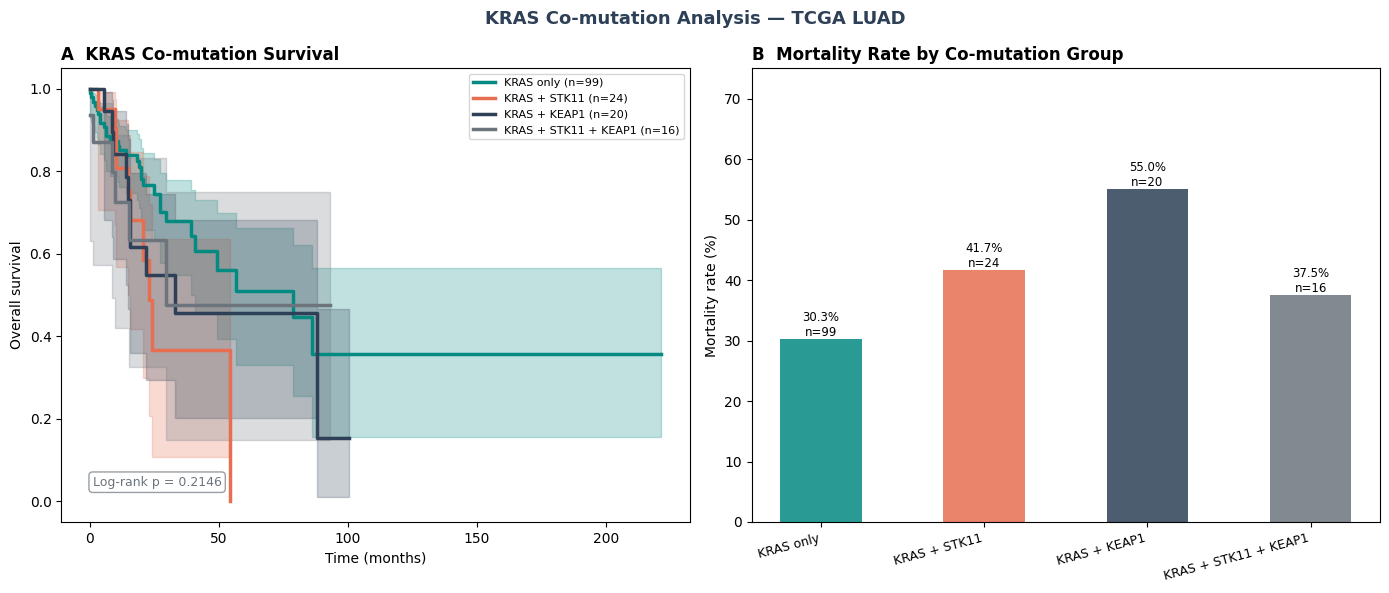

In [30]:
COMUT_COLORS = {
    "KRAS only":            COLORS["secondary"],
    "KRAS + STK11":         COLORS["warm"],
    "KRAS + KEAP1":         COLORS["primary"],
    "KRAS + STK11 + KEAP1": COLORS["gray"],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("white")

ax0 = axes[0]
ax1 = axes[1]

comut_order = ["KRAS only", "KRAS + STK11", "KRAS + KEAP1", "KRAS + STK11 + KEAP1"]

for group in comut_order:
    mask = kras_df["COMUT_GROUP"] == group
    if mask.sum() < 5:
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(kras_df.loc[mask, "OS_MONTHS"], kras_df.loc[mask, "OS_EVENT"],
            label=f"{group} (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax0, ci_show=True,
                               color=COMUT_COLORS[group], lw=2.5)

res = multivariate_logrank_test(kras_df["OS_MONTHS"], kras_df["COMUT_GROUP"],
                                 kras_df["OS_EVENT"])
ax0.text(0.05, 0.08, f"Log-rank p = {res.p_value:.4f}",
         transform=ax0.transAxes, fontsize=9, color=COLORS["gray"],
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["gray"], alpha=0.7))
ax0.set_xlabel("Time (months)")
ax0.set_ylabel("Overall survival")
ax0.set_title("A  KRAS Co-mutation Survival", fontweight="bold", loc="left")
ax0.legend(fontsize=8, loc="upper right")

stats = []
for group in comut_order:
    subset = kras_df[kras_df["COMUT_GROUP"] == group]
    stats.append({
        "group": group,
        "n": len(subset),
        "event_rate": subset["OS_EVENT"].mean() * 100,
    })

stats_df = pd.DataFrame(stats)
colors_bar = [COMUT_COLORS[g] for g in stats_df["group"]]
bars = ax1.bar(range(len(stats_df)), stats_df["event_rate"],
               color=colors_bar, alpha=0.85, width=0.5)
for bar, row in zip(bars, stats_df.itertuples()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{row.event_rate:.1f}%\nn={row.n}", ha="center", fontsize=8.5)
ax1.set_xticks(range(len(stats_df)))
ax1.set_xticklabels(stats_df["group"], rotation=15, ha="right", fontsize=9)
ax1.set_ylabel("Mortality rate (%)")
ax1.set_title("B  Mortality Rate by Co-mutation Group", fontweight="bold", loc="left")
ax1.set_ylim(0, 75)

fig.suptitle("KRAS Co-mutation Analysis — TCGA LUAD",
             fontsize=13, fontweight="bold", color=COLORS["primary"])

plt.tight_layout()
plt.savefig("../notebooks/figures/fig8_kras_comutations.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

### Key Findings — KRAS Co-mutation Analysis

> **Important caveat:** Small sample sizes (n=16–24 per co-mutation group) 
> result in very wide confidence intervals — all findings should be 
> interpreted as exploratory and hypothesis-generating only.

- **No statistically significant survival difference** across co-mutation 
  groups (log-rank p = 0.2146) — likely due to limited power given small 
  group sizes
- **KRAS only has the best survival** (30.3% mortality) — consistent with 
  co-mutations adding adverse biological complexity
- **KRAS + KEAP1 has the highest mortality (55.0%)** — both in the KM curve 
  and mortality rate bar, suggesting KEAP1 co-mutation may have a stronger 
  adverse effect than STK11 in this cohort
- **KRAS + STK11 curve reaches 0 at ~54 months** — not because all 
  patients died (41.7% mortality, 10/24 deaths), but because the last 
  observed event in this group is a death at 54 months with no patients 
  remaining at risk beyond that point. This reflects the shortest 
  follow-up window among all groups, not universal mortality.
> **Methodological note — when KM curves reach zero:** A KM curve 
> reaching 0 does not necessarily mean all patients died. It means 
> the last observed event in that group was a death, with no patients 
> remaining under active follow-up after that point. In the KRAS+STK11 
> group, 14 of 24 patients were **censored** (left the study alive) 
> before the last observed death at 54 months — hence 41.7% overall 
> mortality despite the curve reaching 0. This is why clinical 
> publications typically truncate KM curves when few patients remain 
> at risk — to avoid visually misleading interpretations. The number 
> of patients still at risk at each timepoint is often shown below 
> the x-axis (a "risk table") for transparency.      
- **KRAS + STK11 + KEAP1 (gray) and KRAS + KEAP1 (navy) both reach ~100 
  months** but KEAP1 has higher overall mortality (55% vs 37.5%) — 
  consistent with what you observe in both panels
- These findings are directionally consistent with published literature 
  but do not reach significance — a larger cohort would be needed to 
  confirm these trends

In [23]:
subset = kras_df[kras_df["COMUT_GROUP"] == "KRAS + STK11"]
print("n:", len(subset))
print("Events (deaths):", subset["OS_EVENT"].sum())
print("Censored:", (subset["OS_EVENT"]==0).sum())
print("\nOS_MONTHS range:", subset["OS_MONTHS"].min(), "—", subset["OS_MONTHS"].max())
print("\nDetalle:")
print(subset[["PATIENT_ID", "OS_MONTHS", "OS_EVENT"]].sort_values("OS_MONTHS"))

n: 24
Events (deaths): 10
Censored: 14

OS_MONTHS range: 0.427392577 — 54.34460992

Detalle:
       PATIENT_ID  OS_MONTHS  OS_EVENT
513  TCGA-NJ-A55O   0.427393         0
468  TCGA-99-8032   1.446559         0
510  TCGA-NJ-A4YP   1.643818         0
15   TCGA-05-4415   2.991748         1
348  TCGA-78-7161   9.567018         1
499  TCGA-MP-A4TD  10.093040         1
149  TCGA-50-7109  10.125916         1
282  TCGA-67-3774  12.657396         0
281  TCGA-67-3774  12.657396         0
155  TCGA-53-7813  13.939573         0
392  TCGA-86-8359  14.597100         1
233  TCGA-55-8615  14.662853         0
16   TCGA-05-4417  14.958740         0
220  TCGA-55-8299  15.419009         1
214  TCGA-55-8203  17.983365         0
439  TCGA-95-A4VP  19.890193         0
226  TCGA-55-8508  20.284709         0
337  TCGA-78-7148  20.580596         1
347  TCGA-78-7160  22.914817         1
63   TCGA-44-6144  23.769603         0
402  TCGA-86-A4JF  24.229871         1
380  TCGA-86-8054  37.742052         0
375  TCGA-

In [31]:
# Risk table — patients at risk at key timepoints
timepoints = [0, 25, 50, 75, 100]

rows = []
for group in comut_order:
    mask = kras_df["COMUT_GROUP"] == group
    subset = kras_df[mask]
    kmf = KaplanMeierFitter()
    kmf.fit(subset["OS_MONTHS"], subset["OS_EVENT"])
    row = {"Group": group}
    for t in timepoints:
        at_risk = (subset["OS_MONTHS"] >= t).sum()
        row[f"t={t}mo"] = at_risk
    rows.append(row)

risk_table = pd.DataFrame(rows).set_index("Group")
print("Patients at risk:")
print(risk_table.to_string())

Patients at risk:
                      t=0mo  t=25mo  t=50mo  t=75mo  t=100mo
Group                                                       
KRAS only                99      38      12       9        2
KRAS + STK11             24       3       1       0        0
KRAS + KEAP1             20       8       4       4        1
KRAS + STK11 + KEAP1     16       5       2       2        0


### Patients at Risk — Interpretation

The risk table confirms the key limitation of this analysis:

- **KRAS + STK11 drops to 3 patients by 25 months and 0 by 75 months** — 
  explaining why the KM curve reaches 0 and why confidence intervals are 
  so wide. There are simply no patients left under observation after 50 months.
- **KRAS only retains the most patients at risk** throughout follow-up 
  (12 at 50 months, 2 at 100 months) — making it the most reliable curve
- **All co-mutation groups have fewer than 5 patients at risk by 75 months** — 
  any survival differences beyond that point should not be interpreted

This is why clinical publications include risk tables alongside KM curves — 
they make the reliability of each part of the curve transparent to the reader.

## 9. Multivariable Cox Proportional Hazards Model

So far all analyses have been univariate — one variable at a time. 
A multivariable Cox model asks: **which clinical and molecular features 
are independently prognostic after controlling for all others?**

We integrate:
- **Clinical:** age, pathologic stage
- **Molecular:** key driver mutations (TP53, KRAS, EGFR, STK11, KEAP1)
- **Genomic:** TMB, aneuploidy score

This mirrors real-world evidence study design — where multiple confounders 
must be controlled simultaneously to isolate the effect of each variable.

In [32]:
cox_df = df[["OS_MONTHS", "OS_EVENT", 
             "AGE", "STAGE_SIMPLE",
             "TMB_NONSYNONYMOUS", "ANEUPLOIDY_SCORE",
             "TP53_MUT", "KRAS_MUT", "EGFR_MUT", 
             "STK11_MUT", "KEAP1_MUT"]].copy()

# Encode stage
stage_map = {"I": 1, "II": 2, "III": 3, "IV": 4}
cox_df["STAGE_NUM"] = cox_df["STAGE_SIMPLE"].map(stage_map)

cox_df = cox_df.drop(columns=["STAGE_SIMPLE"])
cox_df = cox_df.dropna()

print(f"Cox dataset: {cox_df.shape}")
print(f"Events: {cox_df['OS_EVENT'].sum()}")
print(f"\nFeature summary:")
print(cox_df.describe().round(2))

Cox dataset: (485, 11)
Events: 172

Feature summary:
       OS_MONTHS  OS_EVENT     AGE  TMB_NONSYNONYMOUS  ANEUPLOIDY_SCORE  \
count     485.00    485.00  485.00             485.00            485.00   
mean       29.02      0.35   65.29              10.37             15.09   
std        29.09      0.48   10.08              10.80              7.81   
min         0.00      0.00   33.00               0.00              0.00   
25%        13.64      0.00   59.00               2.90              8.00   
50%        21.44      0.00   66.00               7.00             16.00   
75%        36.07      1.00   73.00              14.07             21.00   
max       238.29      1.00   88.00              67.20             32.00   

       TP53_MUT  KRAS_MUT  EGFR_MUT  STK11_MUT  KEAP1_MUT  STAGE_NUM  
count    485.00    485.00    485.00     485.00     485.00     485.00  
mean       0.53      0.31      0.14       0.15       0.19       1.73  
std        0.50      0.46      0.34       0.35       0.40 

In [33]:
from lifelines import CoxPHFitter

features = ["AGE", "STAGE_NUM", "TMB_NONSYNONYMOUS", "ANEUPLOIDY_SCORE",
            "TP53_MUT", "KRAS_MUT", "EGFR_MUT", "STK11_MUT", "KEAP1_MUT"]

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df[["OS_MONTHS", "OS_EVENT"] + features],
        duration_col="OS_MONTHS", event_col="OS_EVENT")

cph.print_summary()
print(f"\nC-index: {cph.concordance_index_:.3f}")

<lifelines.CoxPHFitter: fitted with 485 total observations, 313 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_EVENT'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 485
number of events observed = 172
   partial log-likelihood = -886.78
         time fit was run = 2026-05-15 13:52:18 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
AGE                0.01      1.01      0.01           -0.00            0.03                1.00                1.03
STAGE_NUM          0.38      1.46      0.07            0.24            0.51                1.28                1.67
TMB_NONSYNONYMOUS -0.00      1.00      0.01           -0.02            0.01                0.98                1.01
ANEUPLOIDY_SCORE  -0.00      1.00      0.01           -0.02            0.02                0.98                1.02
TP53_MUT           0.33      1.39      0.15            0.03            0.63                1.03                1.87
KRAS_MUT           0.15      1.16      0.15           -0.15            0.45                0.86                1.56
EGFR_MUT           0.13      1.14      0.20           -0.26            0.52                0.77                1.68
STK11_MUT          0.51      1.67      0.19            0.14            0.89                1.15                2.43
KEAP1_MUT          0.09      1.09      0.16           -0.23            0.41                0.79                1.51

                   cmp to     z      p  -log2(p)
covariate                                       
AGE                  0.00  1.61   0.11      3.23
STAGE_NUM            0.00  5.55 <0.005     25.06
TMB_NONSYNONYMOUS    0.00 -0.49   0.62      0.68
ANEUPLOIDY_SCORE     0.00 -0.20   0.84      0.25
TP53_MUT             0.00  2.18   0.03      5.10
KRAS_MUT             0.00  0.98   0.33      1.61
EGFR_MUT             0.00  0.66   0.51      0.97
STK11_MUT            0.00  2.70   0.01      7.16
KEAP1_MUT            0.00  0.55   0.58      0.78
---
Concordance = 0.71
Partial AIC = 1791.55
log-likelihood ratio test = 46.19 on 9 df
-log2(p) of ll-ratio test = 20.78


C-index: 0.707


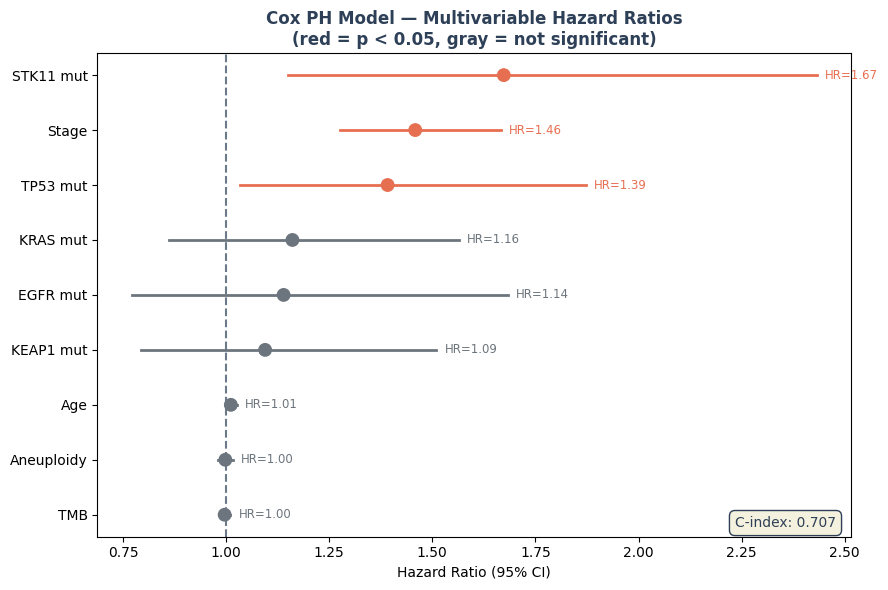

In [34]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")

summary = cph.summary[["exp(coef)", "exp(coef) lower 95%", 
                         "exp(coef) upper 95%", "p"]].copy()

summary.index = ["Age", "Stage", "TMB", "Aneuploidy",
                 "TP53 mut", "KRAS mut", "EGFR mut", 
                 "STK11 mut", "KEAP1 mut"]
summary = summary.sort_values("exp(coef)")

colors_forest = [COLORS["warm"] if p < 0.05 else COLORS["gray"] 
                 for p in summary["p"]]

y_pos = range(len(summary))
ax.scatter(summary["exp(coef)"], y_pos, color=colors_forest, s=80, zorder=3)
for i, (_, row) in enumerate(summary.iterrows()):
    color = COLORS["warm"] if row["p"] < 0.05 else COLORS["gray"]
    ax.plot([row["exp(coef) lower 95%"], row["exp(coef) upper 95%"]], [i, i],
            color=color, lw=2, zorder=2)
    ax.text(row["exp(coef) upper 95%"] + 0.02, i,
            f"HR={row['exp(coef)']:.2f}", va="center", fontsize=8.5,
            color=color)

ax.axvline(1.0, color=COLORS["primary"], ls="--", lw=1.5, alpha=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(summary.index)
ax.set_xlabel("Hazard Ratio (95% CI)")
ax.set_title("Cox PH Model — Multivariable Hazard Ratios\n"
             "(red = p < 0.05, gray = not significant)",
             fontweight="bold", color=COLORS["primary"])

ax.text(0.98, 0.02, f"C-index: {cph.concordance_index_:.3f}",
        transform=ax.transAxes, ha="right", fontsize=10,
        color=COLORS["primary"],
        bbox=dict(boxstyle="round,pad=0.4", fc=COLORS["light"], 
                  ec=COLORS["primary"]))

plt.tight_layout()
plt.savefig("../notebooks/figures/fig9_cox_forest.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

### Key Findings — Multivariable Cox Model (C-index: 0.707)

- **STK11 mutation has the highest hazard ratio (HR=1.67, p=0.01)** — 
  the largest effect size in the model, consistent with its role in 
  immune evasion and therapy resistance
- **Stage is the most statistically robust prognostic factor** 
  (HR=1.46, p<0.005) — most precisely estimated due to larger group 
  sizes; each stage increase raises mortality risk by 46% controlling 
  for all other variables
- **TP53 mutation is independently prognostic** (HR=1.39, p=0.03) — 
  controlling for stage and other mutations, TP53 loss still carries 
  significant adverse effect
- **KRAS, EGFR, and KEAP1 are not independently significant** — their 
  wide confidence intervals crossing 1.0 reflect limited power (small 
  mutated subgroups) rather than absence of biological effect
- **TMB and Aneuploidy are not prognostic** (HR=1.00) — consistent with 
  TMB being predictive of immunotherapy response rather than a general 
  prognostic factor
- **All significant HRs are > 1.0** — no protective factors in this model, 
  as we only included clinical and molecular features, not treatments. 
  In METABRIC, hormone therapy appeared as a protective factor (HR=0.66) 
  because treatment was included
- **Age is not significant** (HR=1.01, p=0.11) — surprising given its 
  strong effect in METABRIC breast cancer, possibly reflecting that LUAD 
  affects a narrower age range (mean 65, std 10)

## 10. ML-Based Prediction of 2-Year Mortality

We frame survival prediction as a binary classification problem: 
did the patient die within 2 years (24 months)?

We chose 2 years because:
- Median OS is ~49 months — so 2-year mortality captures early deaths
- Clinically relevant timepoint for treatment decisions
- Sufficient events for balanced classification (vs 5-year which has fewer events)

Three models compared on held-out test set (25%), using the same 
clinical + molecular features as the Cox model.
> **Note on validation strategy:** We use a single train/test split (75/25) 
> for simplicity and interpretability. In production or publication, 
> **k-fold cross-validation** would be preferred — it rotates the test set 
> across all data, giving more robust AUC estimates with lower variance. 
> A 5-fold CV would use the same 20% test size but repeat the evaluation 
> 5 times with different splits, averaging the results. This is standard 
> practice in clinical ML studies.    

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

CUTOFF = 24  # 2 years

ml_df = cox_df.copy()
ml_df["died_2yr"] = ((ml_df["OS_MONTHS"] <= CUTOFF) & 
                      (ml_df["OS_EVENT"] == 1)).astype(int)

print(f"2-year mortality rate: {ml_df['died_2yr'].mean():.1%}")
print(f"Positive class (died within 2yr): {ml_df['died_2yr'].sum()}")

features = ["AGE", "STAGE_NUM", "TMB_NONSYNONYMOUS", "ANEUPLOIDY_SCORE",
            "TP53_MUT", "KRAS_MUT", "EGFR_MUT", "STK11_MUT", "KEAP1_MUT"]

X = ml_df[features]
y = ml_df["died_2yr"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, 
                            class_weight="balanced", random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, 
                            class_weight="balanced", random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, 
                            random_state=42),
}

aucs = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    proba = model.predict_proba(X_test_s)[:, 1]
    aucs[name] = roc_auc_score(y_test, proba)
    print(f"{name}: AUC = {aucs[name]:.3f}")

2-year mortality rate: 20.8%
Positive class (died within 2yr): 101
Logistic Regression: AUC = 0.775
Random Forest: AUC = 0.743
Gradient Boosting: AUC = 0.645


Best model: Logistic Regression


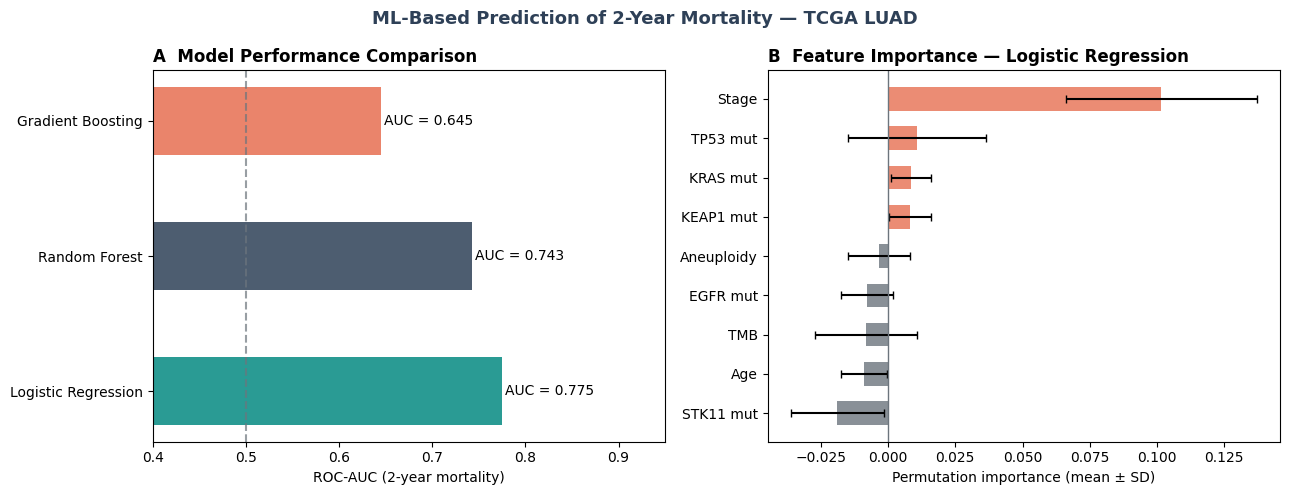

In [36]:
feat_labels = ["Age", "Stage", "TMB", "Aneuploidy",
               "TP53 mut", "KRAS mut", "EGFR mut", 
               "STK11 mut", "KEAP1 mut"]

best_name = max(aucs, key=aucs.get)
best_model = models[best_name]
print(f"Best model: {best_name}")

perm = permutation_importance(best_model, X_test_s, y_test,
                              n_repeats=20, random_state=42)
imp_df = pd.DataFrame({
    "feature":    feat_labels,
    "importance": perm.importances_mean,
    "std":        perm.importances_std
}).sort_values("importance")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

# Panel A — AUC comparison
ax0 = axes[0]
bar_colors = [COLORS["secondary"], COLORS["primary"], COLORS["warm"]]
bars = ax0.barh(list(aucs.keys()), list(aucs.values()),
                color=bar_colors, alpha=0.85, height=0.5)
ax0.axvline(0.5, color=COLORS["gray"], ls="--", lw=1.5, alpha=0.7)
for bar, val in zip(bars, aucs.values()):
    ax0.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f"AUC = {val:.3f}", va="center", fontsize=10)
ax0.set_xlim(0.4, 0.95)
ax0.set_xlabel("ROC-AUC (2-year mortality)")
ax0.set_title("A  Model Performance Comparison", fontweight="bold", loc="left")

# Panel B — Feature importance
ax1 = axes[1]
colors_imp = [COLORS["warm"] if v > 0 else COLORS["gray"] 
              for v in imp_df["importance"]]
ax1.barh(imp_df["feature"], imp_df["importance"], xerr=imp_df["std"],
         color=colors_imp, alpha=0.8, height=0.6, capsize=3)
ax1.axvline(0, color=COLORS["gray"], lw=1)
ax1.set_xlabel("Permutation importance (mean ± SD)")
ax1.set_title(f"B  Feature Importance — {best_name}", 
              fontweight="bold", loc="left")

fig.suptitle("ML-Based Prediction of 2-Year Mortality — TCGA LUAD",
             fontsize=13, fontweight="bold", color=COLORS["primary"])

plt.tight_layout()
plt.savefig("../notebooks/figures/fig10_ml_prediction.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

### Key Findings — ML Prediction of 2-Year Mortality

- **Logistic Regression achieves the best AUC (0.775)** — outperforming 
  Random Forest (0.743) and Gradient Boosting (0.645). With only 485 
  patients and 20% positive class, simpler models generalize better — 
  Gradient Boosting likely overfits to the training set with this 
  sample size
- **Stage is by far the most important feature** (Panel B) — consistent 
  with Cox model results and clinical intuition. All other features have 
  importance close to 0 with wide confidence intervals
- **STK11 permutation importance is near zero (absolute value ~0.025)** 
  with wide CI crossing zero — despite being significant in the Cox model 
  (HR=1.67, p=0.01). What matters is the magnitude, not the sign — a 
  value close to zero means STK11 adds little marginal predictive power 
  to the classifier. This contrasts with Cox where STK11 is independently 
  significant, highlighting that the two methods capture different aspects 
  of feature relevance: permutation importance measures marginal 
  contribution to classification; Cox measures independent effect 
  on survival ranking controlling for confounders.
- **Wide confidence intervals in Panel B** reflect limited test set size 
  (~25 positive events) — permutation importance estimates are unstable 
  with few events. A larger cohort or cross-validation would give more 
  reliable feature importance estimates
- **TMB and Aneuploidy remain uninformative** for 2-year mortality 
  prediction — consistent with Cox results and their role as predictive 
  rather than prognostic biomarkers